In [1]:

import pandas as pd 
import os
import numpy as np
import matplotlib.pyplot as plt 


In [2]:
os.mkdir("./outputs")

In [2]:

df = [] 
folder = f"./outputs/"
for file in os.listdir(folder):
    if file.split(".")[-1] == "csv":
        df.append(pd.read_csv(folder+file))
dfs = pd.concat(df)
dfs = dfs.reset_index()


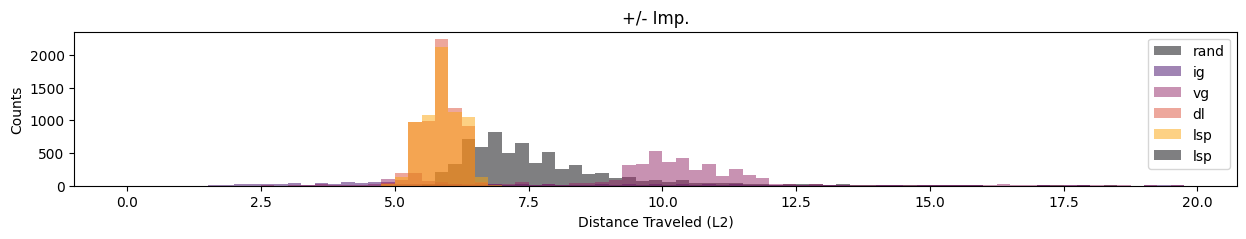

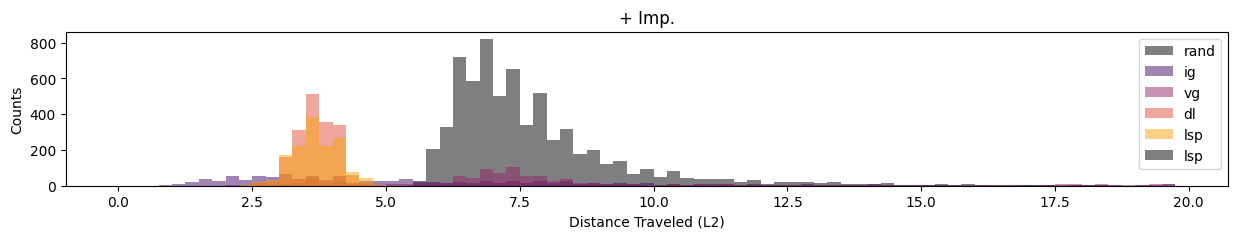

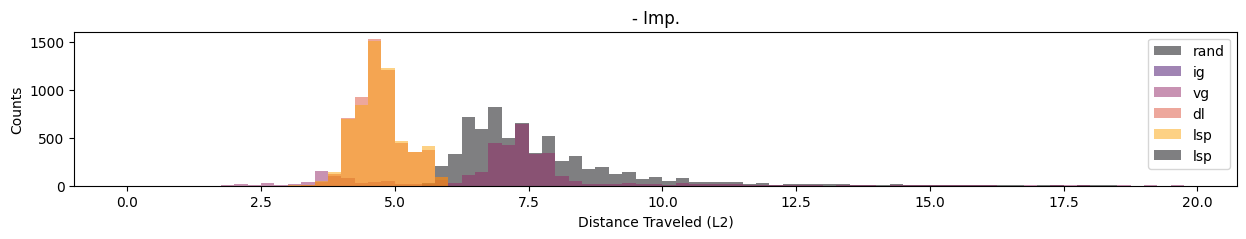

In [4]:
step_size = 0.25
max_num   = 20
bins      = [i*step_size for i in range(0, int(max_num/step_size), 1)]
a         = 0.5

dtype     = "snin"

# Function for creating a stripe plot with inferno colormap
def plt_stripe(dtype, datas, bins, alpha, titles, legend,label):
    fig, ax = plt.subplots(1, 1, figsize=(15, 2))
    
    # Use the inferno colormap
    colormap = plt.cm.inferno
    num_colors = len(datas)
    
    for i, (data, title) in enumerate(zip(datas, titles)): 
        data = [d for d in data if d != 0]
        
        # Get the color from the colormap
        color = colormap(i / num_colors)  # Normalize index to [0, 1] range
        ax.hist(data, bins=bins, alpha=alpha, color=color, label=title)
    
    ax.set_title(label)
    ax.set_xlabel("Distance Traveled (L2)")
    ax.set_ylabel("Counts")
    ax.legend(legend)

#dtypes = ["ri","rip","rin","ani","anip","anin"]
dtypes = ["ri","rip","rin"]
labels = ["+/- Imp.","+ Imp.","- Imp.","+/- (!) Imp.","+ (!) Imp.","- (!) Imp."]
want   = ["small","small","small","large","large","large"]
legend = ["rand","ig","vg","dl","lsp","lsp"]
#legend = ["rand","ig","vg","dl","dg","dc","ds"]
#legend = ["dl","dg","dc","ds"]
for dtype,label in zip(dtypes,labels): 
    titles = [f"ig_d_r3",f"ig_d_{dtype}",f"vg_d_{dtype}",f"dl_l_sf_d_{dtype}",f"dl_l_sp_d_{dtype}"]
    #titles = [f"ig_d_r3",f"ig_d_{dtype}",f"vg_d_{dtype}",f"dl_l_sf_d_{dtype}",f"dl_g_sf_d_{dtype}",f"dl_s_sf_d_{dtype}"]
    #titles = [f"ig_d_r3",f"ig_d_{dtype}",f"vg_d_{dtype}",f"dl_l_sf_d_{dtype}",f"dl_g_sf_d_{dtype}",f"dl_c_sf_d_{dtype}",f"dl_s_sf_d_{dtype}"]
    #titles = [f"dl_l_sf_d_{dtype}",f"dl_g_sf_d_{dtype}",f"dl_c_sf_d_{dtype}",f"dl_s_sf_d_{dtype}"]
    data   = [dfs[t] for t in titles] 
    plt_stripe(dtype,data,bins,a,titles,legend,label)
    
    #plt.hist(dfs[f"ig_d_r3"], bins=bins, alpha=a)
    #plt.hist(dfs[f"ig_d_1"], bins=bins, alpha=a)
    #plt.hist(dfs[f"ig_d_0"], bins=bins, alpha=a)
    #plt.hist(dfs[f"ig_d_{dtype}"], bins=bins, alpha=a)
    #plt.hist(dfs[f"vg_d_{dtype}"], bins=bins, alpha=a)
    #plt.hist(dfs[f"vg_d_1"], bins=bins, alpha=a)
    #plt.hist(dfs[f"dl_l_sf_d_{dtype}"], bins=bins, alpha=a)
    #plt.hist(dfs[f"dl_c_sf_d_{dtype}"], bins=bins, alpha=a)
    #plt.hist(dfs[f"dl_g_sf_d_{dtype}"], bins=bins, alpha=a)
    #plt.title(dtype)


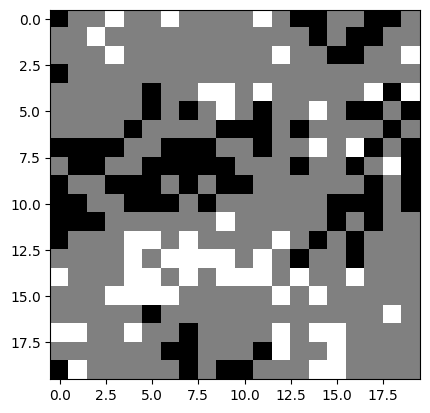

In [152]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'test' is a numpy array of strings that look like lists of numbers
# Clean and convert the string data to numerical format
array_data = []

test = dfs["dl_l_sf_s"].to_numpy()

for row in test:
    # Remove unwanted characters like newlines, extra spaces, etc.
    cleaned_row = row.replace('[', '').replace(']', '').replace('\n', '').replace('  ', ' ')
    # Split the string into individual numbers
    split_row = cleaned_row.split()
    # Convert to float
    float_row = [float(num) for num in split_row]
    array_data.append(float_row)

# Convert list of lists into a NumPy array
array_data = np.array(array_data)

# Reshape the array into a suitable format for an image
# Replace 'height' and 'width' with the correct dimensions based on your data
image_data = array_data[0].reshape((20, 20))

# Plot the image
plt.imshow(image_data, cmap='gray')  # Use grayscale colormap
plt.show()


In [124]:
array_data.shape

(31, 400)

/blue/woodard/stephen.wormald/project/DiffLogic/difflogic/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/blue/woodard/stephen.wormald/project/DiffLogic/difflogic/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/blue/woodard/stephen.wormald/project/DiffLogic/difflogic/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/blue/woodard/stephen.wormald/project/DiffLogic/difflogic/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/blue/woodard/stephen.wormald/project/DiffLogic/difflogic/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid va

   Comparison Type      Data Type       Mean  Standard Deviation  # DNC  \
0         +/- Imp.        ig_d_r3   7.928576            2.790368      8   
1         +/- Imp.        ig_d_ri  13.218796           15.385621   5376   
2         +/- Imp.        vg_d_ri  12.922544           11.886378   1671   
3         +/- Imp.   dl_l_sf_d_ri   5.882973            0.335141     85   
4         +/- Imp.   dl_g_sf_d_ri   6.833755            7.904118    272   
5         +/- Imp.   dl_c_sf_d_ri   5.602483            1.481314      6   
6         +/- Imp.   dl_s_sf_d_ri   7.811476            2.958169      0   
7         +/- Imp.   dl_l_sp_d_ri   5.906541            0.345538     42   
8         +/- Imp.   dl_g_sp_d_ri  11.157788            6.057500    606   
9         +/- Imp.   dl_c_sp_d_ri   5.478975            1.084419      0   
10        +/- Imp.   dl_s_sp_d_ri   7.983742            3.128857      2   
11        +/- Imp.   dl_z_sp_d_ri   7.393231            3.460525      0   
12          + Imp.       

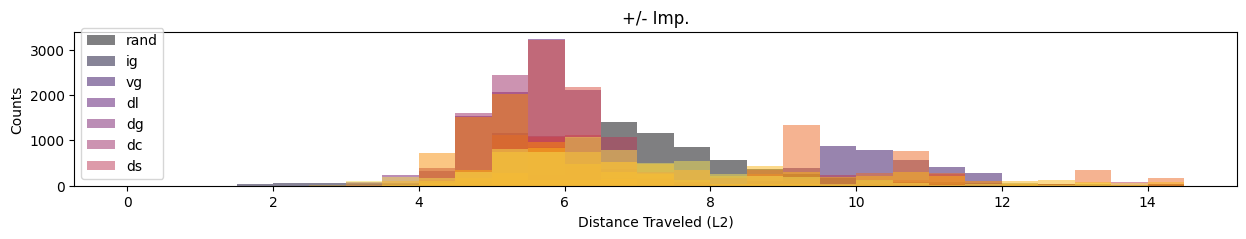

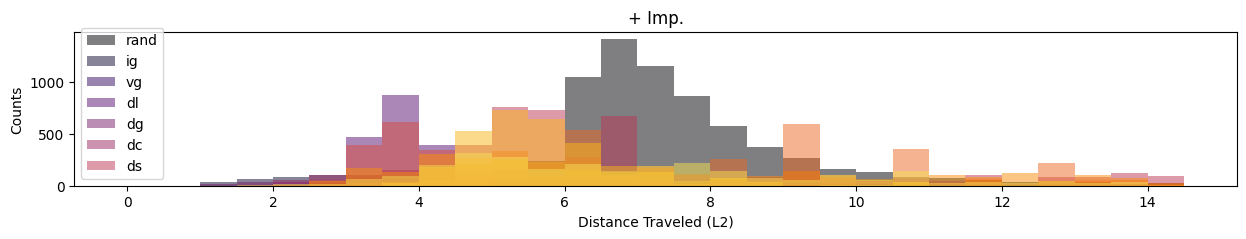

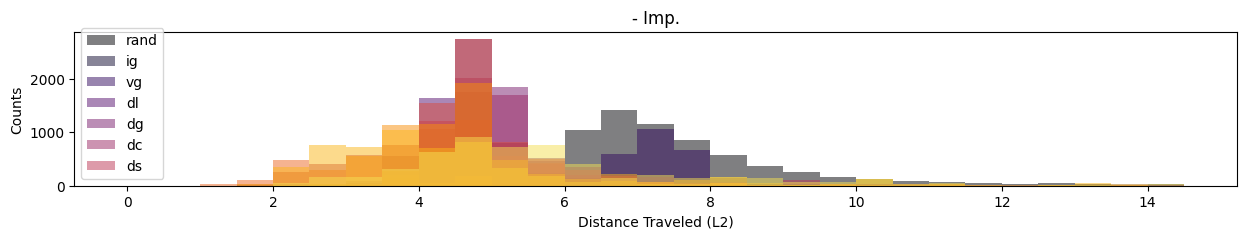

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

step_size = 0.5
max_num = 15
bins = [i * step_size for i in range(0, int(max_num / step_size), 1)]
a = 0.5

dtype = "snin"

# Function for creating a stripe plot with inferno colormap
def plt_stripe(dtype, datas, bins, alpha, titles, legend, label):
    fig, ax = plt.subplots(1, 1, figsize=(15, 2))
    
    # Use the inferno colormap
    colormap = plt.cm.inferno
    num_colors = len(datas)
    
    for i, (data, title) in enumerate(zip(datas, titles)): 
        data = [d for d in data if d != 0]
        
        # Get the color from the colormap
        color = colormap(i / num_colors)  # Normalize index to [0, 1] range
        ax.hist(data, bins=bins, alpha=alpha, color=color, label=title)
    
    ax.set_title(label)
    ax.set_xlabel("Distance Traveled (L2)")
    ax.set_ylabel("Counts")
    ax.legend(legend)

# Create a function to calculate mean and std for the data
def calculate_statistics(datas, titles, label):
    stats = []
    zeros = []  
    largers = []  
    for data, title in zip(datas, titles):
        zeros  = [d for d in data if (d == 0) ]
        larges = [d for d in data if (d > 50) ]
        data   = [d for d in data if (d != 0) and (d < 100) ]
        mean   = np.mean(data)
        std    = np.std(data)
        num_large = len(larges)
        num_zeros = len(zeros)
        num_samples = len(data)
        std    = np.std(data)
        stats.append([label, title, mean, std, num_large, num_zeros, num_samples, num_samples/(num_large + num_zeros + num_samples)*100])
    return stats

# Initialize an empty list to collect the stats
all_stats = []

# Example dtypes, labels, and data titles
#dtypes = ["ri","rip","rin","ani","anip","anin"]
dtypes = ["ri","rip","rin"]
labels = ["+/- Imp.", "+ Imp.", "- Imp.", "+/- (!) Imp.", "+ (!) Imp.", "- (!) Imp."]
legend = ["rand","ig","vg","dl","dg","dc","ds"]

# Iterate through dtypes and labels to calculate and store statistics
for dtype, label in zip(dtypes, labels):
    #titles = [f"ig_d_r3", f"ig_d_{dtype}", f"vg_d_{dtype}", f"dl_s_sf_d_{dtype}"]
    titles = [f"ig_d_r3",f"ig_d_{dtype}",f"vg_d_{dtype}",f"dl_l_sf_d_{dtype}",f"dl_g_sf_d_{dtype}",f"dl_c_sf_d_{dtype}",f"dl_s_sf_d_{dtype}",f"dl_l_sp_d_{dtype}",f"dl_g_sp_d_{dtype}",f"dl_c_sp_d_{dtype}",f"dl_s_sp_d_{dtype}",f"dl_z_sp_d_{dtype}"]
    data = [dfs[t] for t in titles]  # Get the data based on titles
    
    # Calculate mean and std and append the results
    all_stats.extend(calculate_statistics(data, titles, label))
    
    # Optionally, plot the histograms
    plt_stripe(dtype, data, bins, a, titles, legend, label)

# Create a DataFrame to store the statistics
columns = ['Comparison Type', 'Data Type', 'Mean', 'Standard Deviation', '# DNC', '# Zeros', '# Valid', '% Valid']
df_stats = pd.DataFrame(all_stats, columns=columns)

# Display the summary table
print(df_stats)


(array([80.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

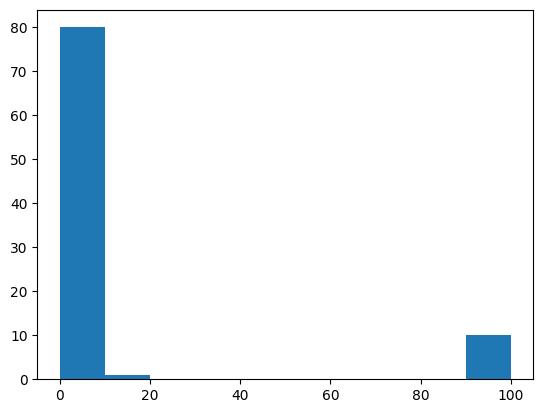

In [32]:
plt.hist(dfs["dl_c_sf_d_rin"])

In [13]:
dfs["ig_d_ri"]

0       0.5
1       0.5
2       0.5
3       0.5
4       0.5
5       0.5
6       0.5
7       0.0
8       0.5
9       0.5
10      0.0
11      0.5
12      0.5
13    100.0
14      0.5
15      0.5
16      0.5
17      0.5
18      0.5
19      0.5
20      0.5
21    100.0
22      0.5
23      0.5
24      0.5
25      0.5
26      0.5
27      0.5
28    100.0
29      0.5
30      0.0
31    100.0
32    100.0
33      0.5
34      0.5
35      0.0
36      0.5
37      0.5
38      0.5
39      0.5
40      0.0
41      0.5
42      0.5
43      0.5
44      0.0
45      0.5
46      0.5
47      0.0
48      0.5
49      0.5
50      0.0
Name: ig_d_ri, dtype: float64

###### exclude = [5,6,7,8,9]#0,1,2,3,4]
exclude = [9]
dtype = "si"
for i in range(10): 
    if i not in exclude: 
        pdf = dfs[dfs["label"]==i]
        data = pdf[f"dl_c_sf_d_{dtype}"]
        plt.hist(data, bins=bins, alpha=a)
plt.legend([i for i in range(10)])


In [61]:
data

9       2.4
23      4.2
31      0.0
47      3.5
72      0.0
       ... 
1355    4.1
1367    3.2
1369    4.5
1401    2.5
1405    0.0
Name: dl_c_sf_d_si, Length: 153, dtype: float64

In [32]:
dfs[f"ig_d_sin"]

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
272   NaN
273   NaN
274   NaN
275   NaN
276   NaN
Name: ig_d_sin, Length: 277, dtype: float64

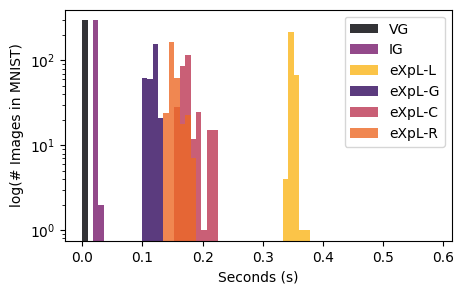

In [160]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming dfs is your DataFrame and has the required data
step_size = 0.009
max_num   = 0.6
bins      = [i * step_size for i in range(0, int(max_num / step_size), 1)]
a         = 0.8

# Define a colormap
cmap = plt.cm.inferno
colors = cmap(np.linspace(0, 1, 7))  # 6 histograms -> 6 colors from the colormap

dtype = "pn"
plt.figure(figsize=(5, 3))
plt.yscale('log')

# Plot histograms with colormap
plt.hist(dfs[f"vg_t"], bins=bins, alpha=a, color=colors[0], label="vg_t")

plt.hist(dfs[f"ig_t"], bins=bins, alpha=a, color=colors[2], label="ig_t")

plt.hist(dfs[f"dl_l_sf_t"], bins=bins, alpha=a, color=colors[5], label="dl_l_sf_t")
plt.hist(dfs[f"dl_g_sf_t"], bins=bins, alpha=a, color=colors[1], label="dl_g_sf_t")
plt.hist(dfs[f"dl_c_sf_t"], bins=bins, alpha=a, color=colors[3], label="dl_c_sf_t")
plt.hist(dfs[f"dl_s_sf_t"], bins=bins, alpha=a, color=colors[4], label="dl_s_sf_t")



# Add labels and legends
plt.xlabel("Seconds (s)")
plt.ylabel("log(# Images in MNIST)")
plt.legend(["VG","IG","eXpL-L","eXpL-G","eXpL-C","eXpL-R"]) 

# Show the plot
plt.show()


In [7]:
dfs[f"dl_l_sf_t"]

0        0.514515
1        0.537618
2        0.473919
3        1.689248
4        0.513002
           ...   
13072    0.509495
13073    0.529126
13074    0.518682
13075    0.473541
13076    0.553931
Name: dl_l_sf_t, Length: 13077, dtype: float64

In [ ]:
step_size = 0.5
max_num   = 15
bins      = [i*step_size for i in range(0, int(max_num/step_size), 1)]
a         = 0.25

dtype     = "pn"

plt.hist(dfs[f"ig_d_r3"], bins=bins, alpha=a)
#plt.hist(dfs[f"ig_d_1"], bins=bins, alpha=a)
#plt.hist(dfs[f"ig_d_0"], bins=bins, alpha=a)
plt.hist(dfs[f"ig_d_{dtype}"], bins=bins, alpha=a)
plt.hist(dfs[f"vg_d_{dtype}"], bins=bins, alpha=a)
#plt.hist(dfs[f"vg_d_1"], bins=bins, alpha=a)
#plt.hist(dfs[f"dl_l_sf_d_{dtype}"], bins=bins, alpha=a)
#plt.hist(dfs[f"dl_c_sf_d_{dtype}"], bins=bins, alpha=a)
plt.hist(dfs[f"dl_g_sf_d_{dtype}"], bins=bins, alpha=a)


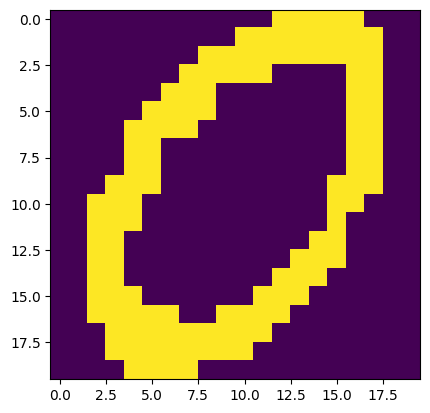

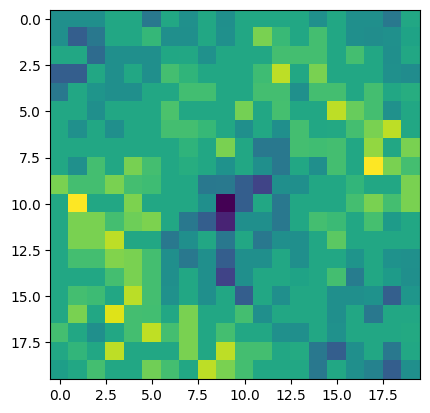

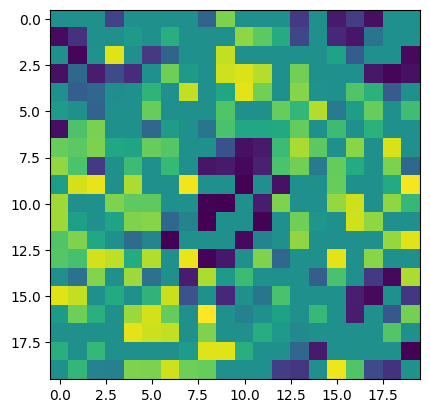

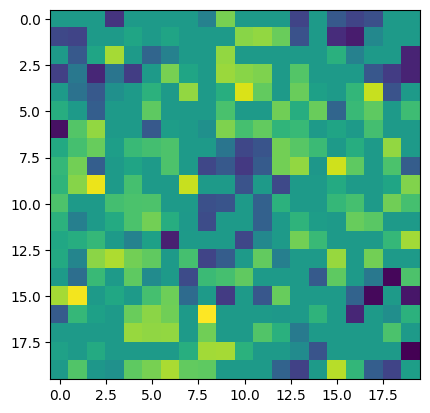

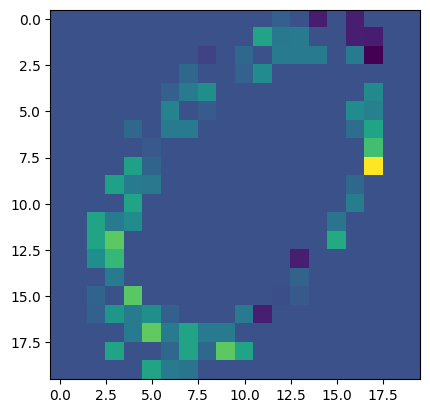

In [201]:
def convert(string): 
    cleaned = string.strip('[]').replace('\n', ' ').split()
    return np.array(cleaned, dtype=float).reshape((20,20))

plt.imshow(convert(dfs["image"][0]))
plt.show()

plt.imshow(convert(dfs["vg_s"][0]))
plt.show()

plt.imshow(convert(dfs["dl_c_sf_s"][0]))
plt.show()

plt.imshow(convert(dfs["dl_g_sf_s"][0]))
plt.show()

plt.imshow(convert(dfs["ig_s"][0]))
plt.show()

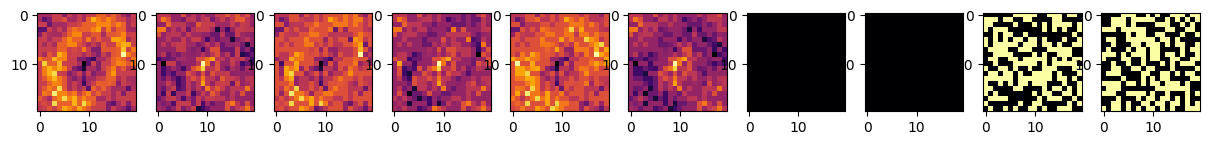

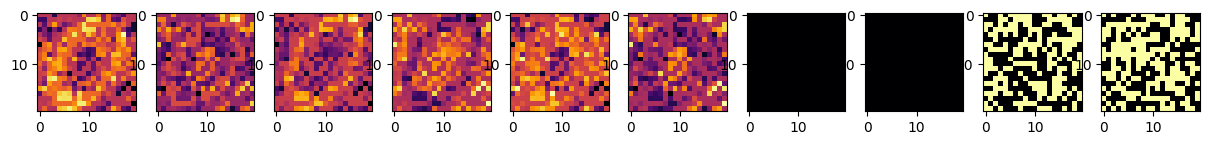

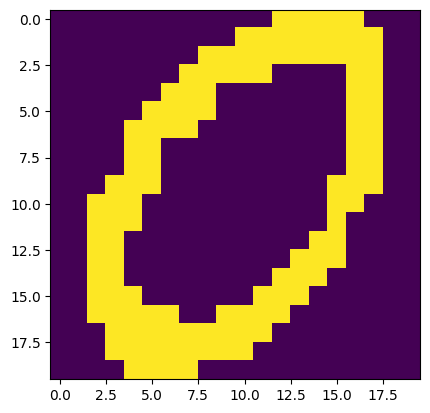

In [200]:
def convert(string): 
    cleaned = string.strip('[]').replace('\n', ' ').split()
    return torch.tensor(np.array(cleaned, dtype=float).reshape((20,20)))

# Helper function to compute the target (end) points when searching for a class change  
def get_targets(image, saliency, n_rands=100): 
    
    image = image
    saliency = saliency
    
    # Convert the saliency map into a unit vector (direction) 
    unit_matrix = saliency.view(-1)
    norm = torch.norm(unit_matrix, p=2)
    unit_vector = unit_matrix / norm
    unit_matrix = unit_vector.view(saliency.shape)
    
    # Initialize all targets
    targets = {} 
    
    # Get the saliency variation targets
    targets["pp"] = image + unit_matrix*200*0.1
    targets["pn"] = image - unit_matrix*200*0.1
    targets["np"] = torch.tensor(np.multiply(image.cpu().detach().numpy()-0.5, np.abs(unit_matrix.cpu().detach().numpy()))+0.5)
    targets["nn"] = torch.tensor(np.multiply(image.cpu().detach().numpy()-0.5,-np.abs(unit_matrix.cpu().detach().numpy()))+0.5)
    targets["sp"] = saliency
    targets["sn"] = -saliency

    # Get the baseline targets 
    targets["1"]  = torch.ones(np.shape(saliency)).to("cuda")
    targets["0"]  = torch.zeros(np.shape(saliency)).to("cuda")
    for i in range(n_rands): 
        targets[f"r{i}"] = (torch.rand(np.shape(saliency))>0.5).int().to("cuda")
    
    return targets

image    = convert(dfs["image"][0])
saliency = convert(dfs["vg_s"][0])
targets  = get_targets(image, saliency)

num_plots = 10 
fig, ax   = plt.subplots(1, num_plots, figsize=(15, 10))
for i, key in enumerate(targets.keys()): 
    ax[i].imshow(targets[key].cpu().detach().numpy(),cmap="inferno")
    if i >= num_plots-1: 
        break 
plt.show()
        
        
image    = convert(dfs["image"][0])
saliency = convert(dfs["dl_g_sf_s"][0])
targets  = get_targets(image, saliency)

num_plots = 10 
fig, ax   = plt.subplots(1, num_plots, figsize=(15, 10))
for i, key in enumerate(targets.keys()): 
    ax[i].imshow(targets[key].cpu().detach().numpy(),cmap="inferno")
    if i >= num_plots-1: 
        break 
plt.show()
plt.imshow(image)
plt.show()

In [122]:
targets["1"]

tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.],
        [1

In [116]:
targets.keys()

dict_keys(['pp', 'pn', 'np', 'nn', 'sp', 'sn', '1', '0', 'r0', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'r13', 'r14', 'r15', 'r16', 'r17', 'r18', 'r19', 'r20', 'r21', 'r22', 'r23', 'r24', 'r25', 'r26', 'r27', 'r28', 'r29', 'r30', 'r31', 'r32', 'r33', 'r34', 'r35', 'r36', 'r37', 'r38', 'r39', 'r40', 'r41', 'r42', 'r43', 'r44', 'r45', 'r46', 'r47', 'r48', 'r49', 'r50', 'r51', 'r52', 'r53', 'r54', 'r55', 'r56', 'r57', 'r58', 'r59', 'r60', 'r61', 'r62', 'r63', 'r64', 'r65', 'r66', 'r67', 'r68', 'r69', 'r70', 'r71', 'r72', 'r73', 'r74', 'r75', 'r76', 'r77', 'r78', 'r79', 'r80', 'r81', 'r82', 'r83', 'r84', 'r85', 'r86', 'r87', 'r88', 'r89', 'r90', 'r91', 'r92', 'r93', 'r94', 'r95', 'r96', 'r97', 'r98', 'r99'])

In [28]:
for i in dfs.keys(): 
    print(i)

label
image
ig_s
ig_t
ig_d_pp
ig_c_pp
ig_d_pn
ig_c_pn
ig_d_np
ig_c_np
ig_d_nn
ig_c_nn
ig_d_sp
ig_c_sp
ig_d_sn
ig_c_sn
ig_d_1
ig_c_1
ig_d_0
ig_c_0
ig_d_r0
ig_c_r0
ig_d_r1
ig_c_r1
ig_d_r2
ig_c_r2
ig_d_r3
ig_c_r3
ig_d_r4
ig_c_r4
vg_s
vg_t
vg_d_pp
vg_c_pp
vg_d_pn
vg_c_pn
vg_d_np
vg_c_np
vg_d_nn
vg_c_nn
vg_d_sp
vg_c_sp
vg_d_sn
vg_c_sn
vg_d_1
vg_c_1
vg_d_0
vg_c_0
vg_d_r0
vg_c_r0
vg_d_r1
vg_c_r1
vg_d_r2
vg_c_r2
vg_d_r3
vg_c_r3
vg_d_r4
vg_c_r4
dl_l_sf_s
dl_l_sf_t
dl_l_sf_d_pp
dl_l_sf_c_pp
dl_l_sf_d_pn
dl_l_sf_c_pn
dl_l_sf_d_np
dl_l_sf_c_np
dl_l_sf_d_nn
dl_l_sf_c_nn
dl_l_sf_d_sp
dl_l_sf_c_sp
dl_l_sf_d_sn
dl_l_sf_c_sn
dl_l_sf_d_1
dl_l_sf_c_1
dl_l_sf_d_0
dl_l_sf_c_0
dl_l_sf_d_r0
dl_l_sf_c_r0
dl_l_sf_d_r1
dl_l_sf_c_r1
dl_l_sf_d_r2
dl_l_sf_c_r2
dl_l_sf_d_r3
dl_l_sf_c_r3
dl_l_sf_d_r4
dl_l_sf_c_r4
dl_c_sf_s
dl_c_sf_t
dl_c_sf_d_pp
dl_c_sf_c_pp
dl_c_sf_d_pn
dl_c_sf_c_pn
dl_c_sf_d_np
dl_c_sf_c_np
dl_c_sf_d_nn
dl_c_sf_c_nn
dl_c_sf_d_sp
dl_c_sf_c_sp
dl_c_sf_d_sn
dl_c_sf_c_sn
dl_c_sf_d_1
dl_c_sf_c_1
dl_c_s